# Hybrid Stochastic-Robust Modeling: "Light Robustness"

In the previous notebooks, we observed that the classic Robust model tends to "over-pack" surgeries because it assumes that patients not covered by the budget $\Gamma$ have zero delay. In reality, every surgery follows a probability distribution.

This notebook implements a **Hybrid Approach**. We adjust the baseline duration of every patient by including their **expected delay** ($\mathbb{E}[delay]$), while still using the uncertainty budget $\Gamma$ to protect against extreme deviations.

## 1. The Mathematical Adjustment

If we assume a uniform distribution $U(0, \alpha)$ for delays, the expected duration of a surgery is:
$$t_{base\_adj} = t_{fixed} + \left( \frac{\alpha}{2} \times t_{sup} \right)$$

The remaining uncertainty to be covered by the robust budget $\Gamma$ becomes the difference between the maximum possible duration and this new baseline:
$$t_{sup\_adj} = \frac{\alpha}{2} \times t_{sup}$$

In [1]:
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os  # <--- Ajoute cet import s'il n'y est pas

# --- Gestion des dossiers de sortie ---
OUTPUT_DIR = "results_hybrid"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Dossier '{OUTPUT_DIR}' prêt pour les exports.")

In [3]:
# ==========================================
# 1. CONFIGURATION & LOADING
# ==========================================
FILENAME = "data/surgery_data.xlsx"
H_REGULAR = 8.0
MAX_TOTAL_TIME = 10.0
GAMMAS_TO_TEST = range(1, 7)
ALPHAS_TO_TEST = [0.8, 1.0, 1.2, 1.5]
N_SCENARIOS = 100
N_TEST_SETS = 3

try:
    df = pd.read_excel(FILENAME, sheet_name="Patients")
    df.columns = ['Patient_ID', 'Spec_ID', 'Specialty', 'Duration', 'Overtime']
    df_costs = pd.read_excel(FILENAME, sheet_name="Specialties")
    df['Specialty'] = df['Specialty'].str.strip().str.upper()
    df_costs['names'] = df_costs['names'].str.strip().str.upper()
except FileNotFoundError:
    print(f"ERROR: File '{FILENAME}' not found.")
    exit()

patients = [f"P{i}" for i in df['Patient_ID']]
specialties = df['Specialty'].unique().tolist()
days = list(range(1, 8))
patient_map = {name: i for i, name in enumerate(patients)}
patient_specialty = {f"P{row.Patient_ID}": row.Specialty for _, row in df.iterrows()}

# ORIGINAL Dictionaries (Reality, used for simulation)
t_fixe = {f"P{row.Patient_ID}": row.Duration for _, row in df.iterrows()}
t_sup = {f"P{row.Patient_ID}": row.Overtime for _, row in df.iterrows()}

base_fixed_costs = {row['names']: row['fixed cost'] for _, row in df_costs.iterrows()}
base_overtime_costs = {row['names']: row['overtime cost (per h)'] for _, row in df_costs.iterrows()}

C_jk, C_prime_jk = {}, {}
for j in specialties:
    for k in days:
        multiplier = 1.0 if k <= 5 else (1.25 if k == 6 else 1.8)
        C_jk[(j, k)] = base_fixed_costs[j] * multiplier
        C_prime_jk[(j, k)] = base_overtime_costs[j] * multiplier

### Implementing the Hybrid Logic in PuLP

In this step, we construct our `solve_hybrid_model` function. Notice how the core constraints have been adapted:
Instead of passing the raw baseline and maximum durations, the solver dynamically accepts `current_t_fixe_hyb` (the expected duration) and `current_t_sup_hyb` (the remaining uncertainty). 

This subtle shift mathematically forces the optimizer to allocate a realistic buffer for *every* scheduled patient, preventing the "dense packing" trap of the purely robust model. We also include a Monte Carlo simulation function (`run_simulation`) to stress-test our schedules against 100 randomly generated scenarios.

## 2. Hybrid Robust Solver

The structure remains the same as the robust model, but it now "sees" the weight of every patient more accurately.

In [4]:
def solve_hybrid_model(gamma_val, current_t_fixe_hyb, current_t_sup_hyb):
    model = pulp.LpProblem(f"Hybrid_Gamma_{gamma_val}", pulp.LpMinimize)
    
    x = pulp.LpVariable.dicts("X", (patients, days), cat='Binary')
    y = pulp.LpVariable.dicts("Y", (specialties, days), cat='Binary')
    tau = pulp.LpVariable.dicts("Tau", (specialties, days), lowBound=0)
    q = pulp.LpVariable.dicts("q", (specialties, days), lowBound=0)
    r = pulp.LpVariable.dicts("r", (patients, days), lowBound=0)
    
    model += pulp.lpSum(C_jk[(j, k)] * y[j][k] + C_prime_jk[(j, k)] * tau[j][k] for j in specialties for k in days)

    for i in patients: model += pulp.lpSum(x[i][k] for k in days) == 1
    for k in days: model += pulp.lpSum(y[j][k] for j in specialties) <= 1
    for i in patients:
        for k in days: model += x[i][k] <= y[patient_specialty[i]][k]

    for j in specialties:
        p_in_j = [i for i in patients if patient_specialty[i] == j]
        for k in days:
            # The solver uses the dynamically calculated expected value!
            lhs = pulp.lpSum(current_t_fixe_hyb[i]*x[i][k] for i in p_in_j) + \
                  gamma_val * q[j][k] + \
                  pulp.lpSum(r[i][k] for i in p_in_j)
            
            model += lhs - H_REGULAR * y[j][k] <= tau[j][k]
            
            for i in p_in_j:
                model += q[j][k] + r[i][k] >= current_t_sup_hyb[i] * x[i][k]
                
            model += tau[j][k] <= (MAX_TOTAL_TIME - H_REGULAR) * y[j][k]

    solver = pulp.GUROBI(msg=0) if pulp.GUROBI().available() else pulp.PULP_CBC_CMD(msg=0)
    model.solve(solver)
    return model.status, x, y

def run_simulation(x, y, scenario_matrix):
    n_sims = scenario_matrix.shape[0]
    violations, costs = 0, []
    fixed = sum(C_jk[(j, k)] for j in specialties for k in days if y[j][k].varValue > 0.5)
    for s in range(n_sims):
        alpha_row, sc_overtime_cost, feasible = scenario_matrix[s], 0, True
        for k in days:
            active_j = next((j for j in specialties if y[j][k].varValue > 0.5), None)
            if active_j:
                p_on_day = [i for i in patients if x[i][k].varValue > 0.5]
                real_t = sum(t_fixe[i] + alpha_row[patient_map[i]] * t_sup[i] for i in p_on_day)
                if real_t > MAX_TOTAL_TIME: feasible = False
                sc_overtime_cost += max(0, real_t - H_REGULAR) * C_prime_jk[(active_j, k)]
        if not feasible: violations += 1
        costs.append(fixed + sc_overtime_cost)
    return 100 * (1 - violations / n_sims), np.mean(costs)

def export_results(solutions, alpha, cur_t_fixe_hyb, filename):
    with pd.ExcelWriter(filename) as writer:
        for g, (x_sol, y_sol) in solutions.items():
            data = []
            for k in days:
                active_j = next((j for j in specialties if y_sol[j][k].varValue > 0.5), "None")
                pts = [i for i in patients if x_sol[i][k].varValue > 0.5]
                for p in pts:
                    data.append({"Gamma": g, "Day": k, "Spec": active_j, "Patient": p, "Base": t_fixe[p], "Hybrid_Base": cur_t_fixe_hyb[p]})
            pd.DataFrame(data).to_excel(writer, sheet_name=f"Gamma_{g}", index=False)
    print(f"Exported: {filename}")

## 3. Sensitivity Analysis on $\alpha$

We will now execute the hybrid model across different levels of expected delay ($\alpha$). 
By testing $\alpha \in \{0.8, 1.0, 1.2, 1.5\}$, we can observe how increasing the expected baseline duration shifts the Pareto front. A higher $\alpha$ means the model assumes patients will inherently take longer, creating safer but potentially more expensive schedules.

## $\alpha\ = 0.8$


--- Starting Analysis for Alpha = 0.8 ---
Restricted license - for non-production use only - expires 2027-11-29
Restricted license - for non-production use only - expires 2027-11-29
Gamma 1 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 2 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 3 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 4 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 5 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 6 Solved.
Exported: results_hybrid/hybrid_planning_alpha_0.8.xlsx


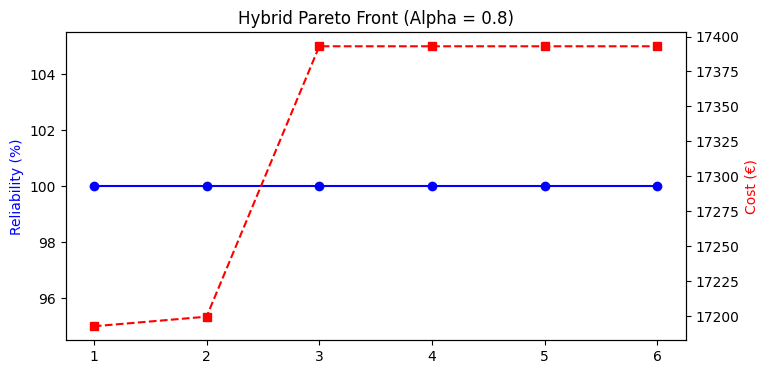

In [5]:
# --- STEP: ANALYSIS FOR A SPECIFIC ALPHA ---
current_alpha = 0.8  

print(f"\n--- Starting Analysis for Alpha = {current_alpha} ---")
# 1. Calculation of hybrid times
t_fixe_hyb_cur = {i: t_fixe[i] + (current_alpha / 2) * t_sup[i] for i in patients}
t_sup_hyb_cur = {i: (current_alpha / 2) * t_sup[i] for i in patients}

# 2. Model resolution
solutions = {}
for g in GAMMAS_TO_TEST:
    status, x_s, y_s = solve_hybrid_model(g, t_fixe_hyb_cur, t_sup_hyb_cur)
    if pulp.LpStatus[status] == 'Optimal':
        solutions[g] = (x_s, y_s)
        print(f"Gamma {g} Solved.")

# 3. Export to Excel
file_name_xlsx = f"hybrid_planning_alpha_{current_alpha}.xlsx"
path_xlsx = os.path.join(OUTPUT_DIR, file_name_xlsx)
export_results(solutions, current_alpha, t_fixe_hyb_cur, path_xlsx)

# 4. Simulation & Graph
np.random.seed(42)
test_sets = [np.random.uniform(0, current_alpha, size=(N_SCENARIOS, len(patients))) for _ in range(N_TEST_SETS)]

valid_g, r_m, c_m = [], [], []
for g, (x_s, y_s) in solutions.items():
    res = [run_simulation(x_s, y_s, ts) for ts in test_sets]
    valid_g.append(g); r_m.append(np.mean([x[0] for x in res])); c_m.append(np.mean([x[1] for x in res]))

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(valid_g, r_m, 'b-o', label="Reliability")
ax1.set_ylabel("Reliability (%)", color='b')
ax2 = ax1.twinx()
ax2.plot(valid_g, c_m, 'r--s', label="Cost")
ax2.set_ylabel("Cost (€)", color='r')
plt.title(f"Hybrid Pareto Front (Alpha = {current_alpha})")

image_name = f"hybrid_pareto_alpha_{current_alpha}.png"
plt.savefig(os.path.join(OUTPUT_DIR, image_name), bbox_inches='tight', dpi=150)
    

plt.show()

## $\alpha\ = 1.0 $


--- Starting Analysis for Alpha = 1.0 ---
Restricted license - for non-production use only - expires 2027-11-29
Gamma 1 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 2 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 3 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 4 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 5 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 6 Solved.
Exported: results_hybrid/hybrid_planning_alpha_1.0.xlsx


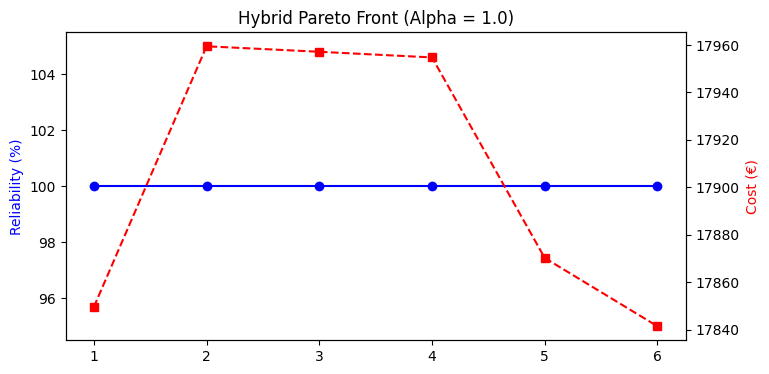

In [6]:
# --- STEP: ANALYSIS FOR A SPECIFIC ALPHA ---
current_alpha = 1.0  

print(f"\n--- Starting Analysis for Alpha = {current_alpha} ---")
# 1. Calculation of hybrid times
t_fixe_hyb_cur = {i: t_fixe[i] + (current_alpha / 2) * t_sup[i] for i in patients}
t_sup_hyb_cur = {i: (current_alpha / 2) * t_sup[i] for i in patients}

# 2. Model resolution
solutions = {}
for g in GAMMAS_TO_TEST:
    status, x_s, y_s = solve_hybrid_model(g, t_fixe_hyb_cur, t_sup_hyb_cur)
    if pulp.LpStatus[status] == 'Optimal':
        solutions[g] = (x_s, y_s)
        print(f"Gamma {g} Solved.")

# 3. Export to Excel
file_name_xlsx = f"hybrid_planning_alpha_{current_alpha}.xlsx"
path_xlsx = os.path.join(OUTPUT_DIR, file_name_xlsx)
export_results(solutions, current_alpha, t_fixe_hyb_cur, path_xlsx)

# 4. Simulation & Graph
np.random.seed(42)
test_sets = [np.random.uniform(0, current_alpha, size=(N_SCENARIOS, len(patients))) for _ in range(N_TEST_SETS)]

valid_g, r_m, c_m = [], [], []
for g, (x_s, y_s) in solutions.items():
    res = [run_simulation(x_s, y_s, ts) for ts in test_sets]
    valid_g.append(g); r_m.append(np.mean([x[0] for x in res])); c_m.append(np.mean([x[1] for x in res]))

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(valid_g, r_m, 'b-o', label="Reliability")
ax1.set_ylabel("Reliability (%)", color='b')
ax2 = ax1.twinx()
ax2.plot(valid_g, c_m, 'r--s', label="Cost")
ax2.set_ylabel("Cost (€)", color='r')
plt.title(f"Hybrid Pareto Front (Alpha = {current_alpha})")

image_name = f"hybrid_pareto_alpha_{current_alpha}.png"
plt.savefig(os.path.join(OUTPUT_DIR, image_name), bbox_inches='tight', dpi=150)
    
plt.show()

## $\alpha\ = 1.2 $


--- Starting Analysis for Alpha = 1.2 ---
Restricted license - for non-production use only - expires 2027-11-29
Gamma 1 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 2 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 3 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 4 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 5 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Exported: results_hybrid/hybrid_planning_alpha_1.2.xlsx


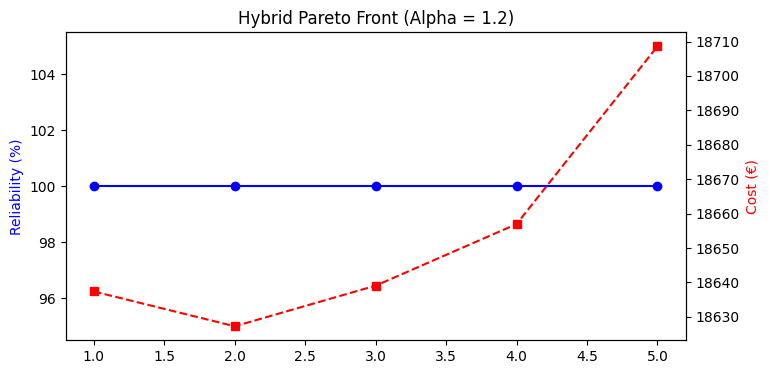

In [7]:
# --- STEP: ANALYSIS FOR A SPECIFIC ALPHA ---
current_alpha = 1.2 

print(f"\n--- Starting Analysis for Alpha = {current_alpha} ---")
# 1. Calculation of hybrid times
t_fixe_hyb_cur = {i: t_fixe[i] + (current_alpha / 2) * t_sup[i] for i in patients}
t_sup_hyb_cur = {i: (current_alpha / 2) * t_sup[i] for i in patients}

# 2. Model resolution
solutions = {}
for g in GAMMAS_TO_TEST:
    status, x_s, y_s = solve_hybrid_model(g, t_fixe_hyb_cur, t_sup_hyb_cur)
    if pulp.LpStatus[status] == 'Optimal':
        solutions[g] = (x_s, y_s)
        print(f"Gamma {g} Solved.")

# 3. Export to Excel
file_name_xlsx = f"hybrid_planning_alpha_{current_alpha}.xlsx"
path_xlsx = os.path.join(OUTPUT_DIR, file_name_xlsx)
export_results(solutions, current_alpha, t_fixe_hyb_cur, path_xlsx)

# 4. Simulation & Graph
np.random.seed(42)
test_sets = [np.random.uniform(0, current_alpha, size=(N_SCENARIOS, len(patients))) for _ in range(N_TEST_SETS)]

valid_g, r_m, c_m = [], [], []
for g, (x_s, y_s) in solutions.items():
    res = [run_simulation(x_s, y_s, ts) for ts in test_sets]
    valid_g.append(g); r_m.append(np.mean([x[0] for x in res])); c_m.append(np.mean([x[1] for x in res]))

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(valid_g, r_m, 'b-o', label="Reliability")
ax1.set_ylabel("Reliability (%)", color='b')
ax2 = ax1.twinx()
ax2.plot(valid_g, c_m, 'r--s', label="Cost")
ax2.set_ylabel("Cost (€)", color='r')
plt.title(f"Hybrid Pareto Front (Alpha = {current_alpha})")

image_name = f"hybrid_pareto_alpha_{current_alpha}.png"
plt.savefig(os.path.join(OUTPUT_DIR, image_name), bbox_inches='tight', dpi=150)
    
plt.show()

## $\alpha\ = 1.5$


--- Starting Analysis for Alpha = 1.5 ---
Restricted license - for non-production use only - expires 2027-11-29
Gamma 1 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Gamma 2 Solved.
Restricted license - for non-production use only - expires 2027-11-29
Restricted license - for non-production use only - expires 2027-11-29
Restricted license - for non-production use only - expires 2027-11-29
Restricted license - for non-production use only - expires 2027-11-29
Exported: results_hybrid/hybrid_planning_alpha_1.5.xlsx


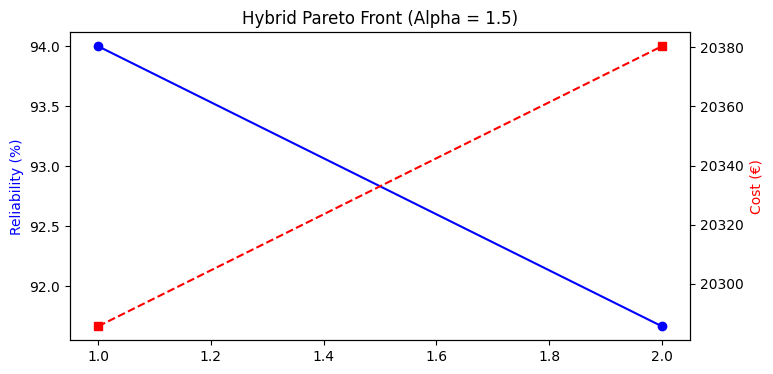

In [8]:
# --- STEP: ANALYSIS FOR A SPECIFIC ALPHA ---
current_alpha = 1.5 

print(f"\n--- Starting Analysis for Alpha = {current_alpha} ---")
# 1. Calculation of hybrid times
t_fixe_hyb_cur = {i: t_fixe[i] + (current_alpha / 2) * t_sup[i] for i in patients}
t_sup_hyb_cur = {i: (current_alpha / 2) * t_sup[i] for i in patients}

# 2. Model resolution
solutions = {}
for g in GAMMAS_TO_TEST:
    status, x_s, y_s = solve_hybrid_model(g, t_fixe_hyb_cur, t_sup_hyb_cur)
    if pulp.LpStatus[status] == 'Optimal':
        solutions[g] = (x_s, y_s)
        print(f"Gamma {g} Solved.")

# 3. Export to Excel
file_name_xlsx = f"hybrid_planning_alpha_{current_alpha}.xlsx"
path_xlsx = os.path.join(OUTPUT_DIR, file_name_xlsx)
export_results(solutions, current_alpha, t_fixe_hyb_cur, path_xlsx)

# 4. Simulation & Graph
np.random.seed(42)
test_sets = [np.random.uniform(0, current_alpha, size=(N_SCENARIOS, len(patients))) for _ in range(N_TEST_SETS)]

valid_g, r_m, c_m = [], [], []
for g, (x_s, y_s) in solutions.items():
    res = [run_simulation(x_s, y_s, ts) for ts in test_sets]
    valid_g.append(g); r_m.append(np.mean([x[0] for x in res])); c_m.append(np.mean([x[1] for x in res]))

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(valid_g, r_m, 'b-o', label="Reliability")
ax1.set_ylabel("Reliability (%)", color='b')
ax2 = ax1.twinx()
ax2.plot(valid_g, c_m, 'r--s', label="Cost")
ax2.set_ylabel("Cost (€)", color='r')
plt.title(f"Hybrid Pareto Front (Alpha = {current_alpha})")

image_name = f"hybrid_pareto_alpha_{current_alpha}.png"
plt.savefig(os.path.join(OUTPUT_DIR, image_name), bbox_inches='tight', dpi=150)

plt.show()


## 4. Final Conclusion on Light Robustness

The Hybrid model acts as a "prudent" planner. By mathematically acknowledging the expected delay of every patient, it naturally spaces out surgeries and closes the loopholes of classic robust optimization. 

**Key Benefits Observed:**
1. **Stabilized Reliability:** It definitively prevents the "reliability collapse" seen at higher $\Gamma$ values in the classic robust model by making the baseline duration statistically realistic.
2. **Proportional Risk Scaling (The $\alpha$ effect):** With the corrected residual variance formula ($t_{sup\_adj} = \frac{\alpha}{2} \cdot t_{sup}$), the model dynamically scales its protection. At extreme stress levels ($\alpha = 1.5$), the solver correctly identifies that the residual variance is huge (75% of the max delay) and naturally generates highly conservative, safe schedules without requiring an artificially huge $\Gamma$.
3. **Operational Sanity:** The resulting schedules are balanced and strictly avoid the "dense-packing" anomaly, making them operationally viable for medical staff.
4. **Best of Both Worlds:** It successfully merges the statistical accuracy of the Stochastic SAA model with the hard worst-case feasibility guarantees of the Robust approach.
